In [1]:
import pandas as pd
import numpy as np
import os 

# import umap
import matplotlib.pyplot as plt
# import scanpy as sc
import seaborn as sns

import glob
import math
import re
import os
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 
matplotlib.rcParams['font.family'] = 'Arial'

In [4]:
cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)

/tmp/ipykernel_435089/286891771.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)


## contact_distance

In [5]:
contact_distance_path = '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_distance'

In [6]:
contact_distance_files = glob.glob(f'{contact_distance_path}/*distance_decay.hdf5')

contact_distance = [pd.read_hdf(file) for file in contact_distance_files]
contact_distance = pd.concat(contact_distance,axis = 0)
contact_distance.drop_duplicates(inplace = True)
contact_distance = contact_distance.loc[cellID_merged.index]

In [7]:
normalized_contact_distance = contact_distance.div(contact_distance.sum(axis=1), axis=0)

In [8]:
# Step 2: Compute the corresponding sizes for each bin
def bin_to_size(bin_number):
    size_kb = 2.5 *2 ** ((bin_number) * 0.125)  # Calculate size in kb
    if size_kb >= 1000:
        return f"{size_kb / 1000:.0f} Mb"  # Convert to Mb if >= 1000 kb
    else:
        return f"{size_kb:.0f} kb"  # Keep in kb otherwise

## short/long ration compare

In [14]:
X = normalized_contact_distance.drop_duplicates().iloc[:, 0:132].copy()

# Ensure bin numbers are numeric
bin_nums = pd.to_numeric(X.columns, errors='coerce')
valid = ~bin_nums.isna()
X = X.loc[:, valid]
bin_nums = bin_nums[valid].astype(float)

left_bp  = 2500.0 * 2**(0.125 * bin_nums.values)
right_bp = 2500.0 * 2**(0.125 * (bin_nums.values + 1.0))

# ranges in bp
SE_lo, SE_hi = 200_000.0, 2_000_000.0         # 200 kb–2 Mb
LE_lo, LE_hi = 20_000_000.0, 100_000_000    # 20–100 Mb

def fmt_bp_label(x):
    if x >= 1_000_000:
        return f"{x / 1_000_000:g} Mb"
    return f"{x / 1_000:g} kb"

se_le_axis_label = (
    f"log$_2$(SE: {fmt_bp_label(SE_lo)}-{fmt_bp_label(SE_hi)} / "
    f"LE: {fmt_bp_label(LE_lo)}-{fmt_bp_label(LE_hi)})"
)

SE_mask = (right_bp > SE_lo) & (left_bp < SE_hi)
LE_mask = (right_bp > LE_lo) & (left_bp < LE_hi)

# Sum across selected columns per row
SE_sum = X.loc[:, SE_mask].sum(axis=1)
LE_sum = X.loc[:, LE_mask].sum(axis=1)

# Ratio (avoid divide-by-zero)
ratio = SE_sum / LE_sum.replace(0, np.nan)

# Remove duplicate indices from Series
SE_sum = SE_sum[~SE_sum.index.duplicated(keep='first')]
LE_sum = LE_sum[~LE_sum.index.duplicated(keep='first')]
ratio = ratio[~ratio.index.duplicated(keep='first')]

# Attach back - remove duplicate indices
sorted_df_ratio = normalized_contact_distance.drop_duplicates(keep='first').copy()
sorted_df_ratio = sorted_df_ratio[~sorted_df_ratio.index.duplicated(keep='first')]
sorted_df_ratio["SE_sum_200kb_2Mb"]   = SE_sum
sorted_df_ratio["LE_sum_20Mb_100Mb"]  = LE_sum
sorted_df_ratio["SE_over_LE_ratio"]   = ratio
sorted_df_ratio["log2_SE_over_LE_ratio"]   = np.log2(ratio)

## Compare whole vs 100k and 60k downsample


In [15]:
def load_downsample_decay(label):
    files = glob.glob(f'{contact_distance_path}/*downsample_{label}_decay.hdf5')
    x = pd.concat([pd.read_hdf(file) for file in files], axis=0)
    x = x[x.index.isin(cellID_merged.index)]
    x = x[~x.index.duplicated(keep='first')]
    
    return x


def add_se_le_ratio(df):
    x = df.drop_duplicates().iloc[:, 0:132].copy()
    bin_nums = pd.to_numeric(x.columns, errors='coerce')
    valid = ~bin_nums.isna()
    x = x.loc[:, valid]
    bin_nums = bin_nums[valid].astype(float)
    # ranges in bp
    SE_lo, SE_hi = 200_000.0, 2_000_000.0         # 200 kb–2 Mb
    LE_lo, LE_hi = 20_000_000.0, 100_000_000    # 20–100 Mb

    left_bp = 2500.0 * 2**(0.125 * bin_nums.values)
    right_bp = 2500.0 * 2**(0.125 * (bin_nums.values + 1.0))
    se_mask = (right_bp > SE_lo) & (left_bp < SE_hi)
    le_mask = (right_bp > LE_lo) & (left_bp < LE_hi)

    out = df.drop_duplicates(keep='first').copy()
    se = x.loc[:, se_mask].sum(axis=1)
    le = x.loc[:, le_mask].sum(axis=1)
    ratio = se / le.replace(0, np.nan)
    out['log2_SE_over_LE_ratio'] = np.log2(ratio)
    return out

whole_ratio = add_se_le_ratio(contact_distance.div(contact_distance.sum(axis=1), axis=0))
downsample_100k = load_downsample_decay('100k')
downsample_60k = load_downsample_decay('60k')
ratio_100k = add_se_le_ratio(downsample_100k.div(downsample_100k.sum(axis=1), axis=0))
ratio_60k = add_se_le_ratio(downsample_60k.div(downsample_60k.sum(axis=1), axis=0))

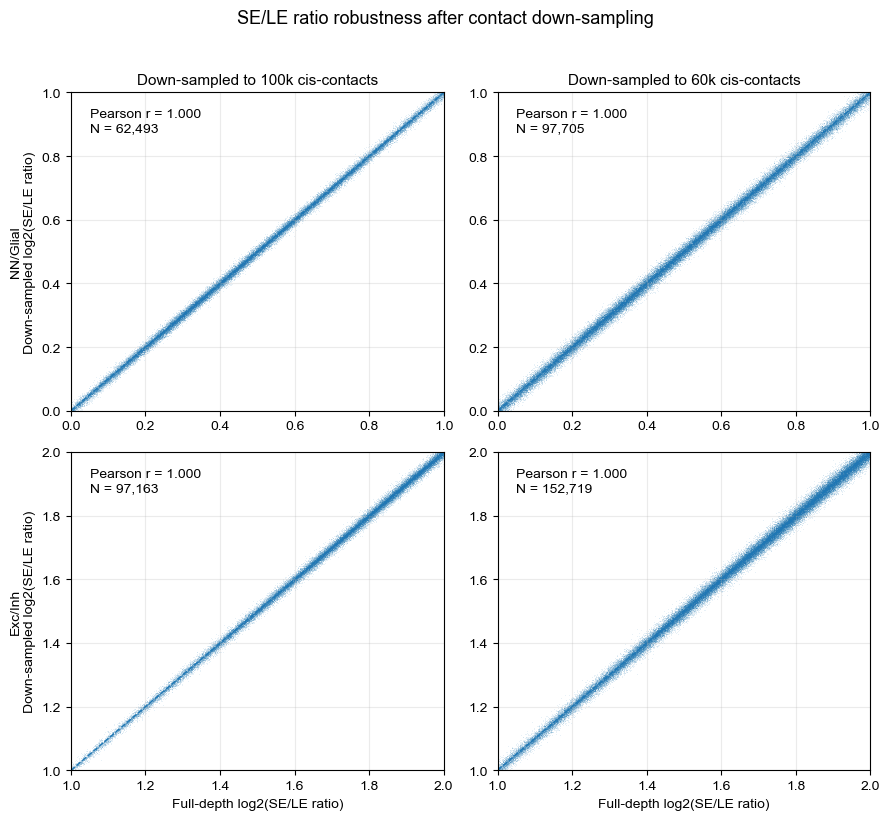

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=False, sharey=False)

comparisons = {
    "100k cis-contacts": ratio_100k,
    "60k cis-contacts": ratio_60k,
}

group_sets = {
    "NN/Glial": ["NN", "Glial"],
    "Exc/Inh": ["Exc", "Inh"],
}

# Set different axis limits for each row/group
axis_lims = {
    "NN/Glial": (0, 1),
    "Exc/Inh": (1, 2),
}

for row_idx, (group_name, l1_values) in enumerate(group_sets.items()):
    for col_idx, (depth_label, down_ratio) in enumerate(comparisons.items()):
        ax = axes[row_idx, col_idx]

        common = (
            whole_ratio.index
            .intersection(down_ratio.index)
            .intersection(cellID_merged.index)
        )

        plot_df = pd.DataFrame({
            "full": whole_ratio.loc[common, "log2_SE_over_LE_ratio"],
            "downsampled": down_ratio.loc[common, "log2_SE_over_LE_ratio"],
            "L1": cellID_merged.loc[common, "L1"],
        }).dropna()

        plot_df = plot_df[plot_df["L1"].isin(l1_values)]

        r = plot_df["full"].corr(plot_df["downsampled"], method="pearson")
        n = plot_df.shape[0]

        ax.scatter(
            plot_df["full"],
            plot_df["downsampled"],
            s=0.1,
            alpha=0.35,
            linewidths=0,
            rasterized=True,
        )

        lims = axis_lims[group_name]
        ax.plot(lims, lims, linestyle="--", linewidth=1)

        ax.text(
            0.05, 0.95,
            f"Pearson r = {r:.3f}\nN = {n:,}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
        )

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.grid(True, alpha=0.25)

        if row_idx == 0:
            ax.set_title(f"Down-sampled to {depth_label}", fontsize=11)

        if col_idx == 0:
            ax.set_ylabel(f"{group_name}\nDown-sampled log2(SE/LE ratio)")
        else:
            ax.set_ylabel("")

        if row_idx == 1:
            ax.set_xlabel("Full-depth log2(SE/LE ratio)")
        else:
            ax.set_xlabel("")

fig.suptitle("SE/LE ratio robustness after contact down-sampling", y=1.02, fontsize=13)
plt.tight_layout()
# plt.savefig("SE_LE_ratio_comparison_downsampled_by_L1_2x2.pdf", bbox_inches="tight", dpi=300)
plt.show()

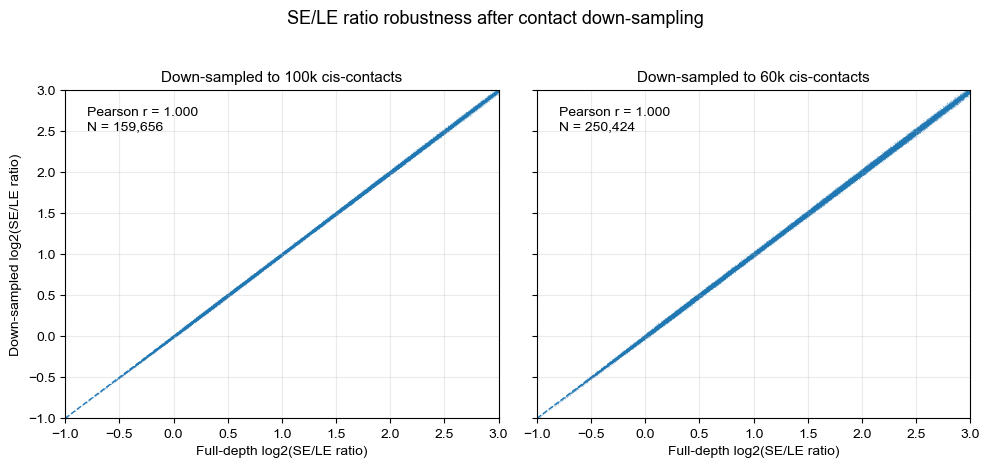

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

comparisons = {
    "100k cis-contacts": ratio_100k,
    "60k cis-contacts": ratio_60k,
}

lims = (-1, 3)

for ax, (label, down_ratio) in zip(axes, comparisons.items()):
    common = whole_ratio.index.intersection(down_ratio.index)

    plot_df = pd.DataFrame({
        "full": whole_ratio.loc[common, "log2_SE_over_LE_ratio"],
        "downsampled": down_ratio.loc[common, "log2_SE_over_LE_ratio"],
    }).dropna()

    r = plot_df["full"].corr(plot_df["downsampled"], method="pearson")
    n = plot_df.shape[0]

    ax.scatter(
        plot_df["full"],
        plot_df["downsampled"],
        s=0.1,
        alpha=0.35,
        linewidths=0,
        rasterized=True,
    )

    ax.plot(lims, lims, linestyle="--", linewidth=1)

    ax.text(
        0.05, 0.95,
        f"Pearson r = {r:.3f}\nN = {n:,}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )

    ax.set_title(f"Down-sampled to {label}", fontsize=11)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Down-sampled log2(SE/LE ratio)")
for ax in axes:
    ax.set_xlabel("Full-depth log2(SE/LE ratio)")

fig.suptitle("SE/LE ratio robustness after contact down-sampling", y=1.03, fontsize=13)
plt.tight_layout()
# plt.savefig("SE_LE_ratio_comparison_downsampled.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Test OPDC biomodality

In [10]:
OPDC_cluster = pd.read_csv('/cndd2/hex002/Luo_Development/hic_contact_dist/OPDC_SELE_clusters.csv',index_col=0)
OPDC_cluster = OPDC_cluster[OPDC_cluster['oL3'] != 'stemODC']

In [12]:
# from diptest import diptest
from sklearn.mixture import GaussianMixture

oL3
adult_ODC    14612
OPC          12457
srODC         6524
ODC           6427
GPC           6328
tOPC          3690
tODC          3481
adult_OPC     2681
2T_GPC         903
Name: count, dtype: int64
Cells with full-depth log2(SE/LE): 57103
Gaussian mixture BIC: 1 mode=78361.2, 2 modes=74373.6, delta=3987.6
Component means: [0.46988021 1.0809318 ]
Component weights: [0.3337475 0.6662525]


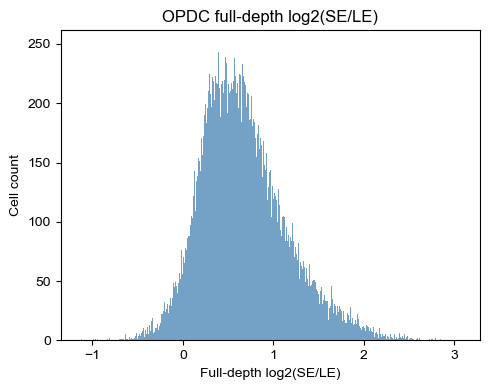

In [18]:
OPDC_SELE_full_depth = OPDC_cluster.join(
    whole_ratio[['log2_SE_over_LE_ratio']],
    how='inner'
).rename(columns={'log2_SE_over_LE_ratio': 'full_depth_log2_SE_LE'})

x = (OPDC_SELE_full_depth['full_depth_log2_SE_LE'].dropna().to_numpy())
print(OPDC_SELE_full_depth['oL3'].value_counts())
print(f'Cells with full-depth log2(SE/LE): {len(x)}')

# dip, pvalue = diptest(x)
# print(f'Hartigan dip test: dip={dip:.4f}, p={pvalue:.4g}')

X = x.reshape(-1, 1)
gmm1 = GaussianMixture(n_components=1, random_state=0).fit(X)
gmm2 = GaussianMixture(n_components=2, random_state=0).fit(X)
bic1 = gmm1.bic(X)
bic2 = gmm2.bic(X)
print(f'Gaussian mixture BIC: 1 mode={bic1:.1f}, 2 modes={bic2:.1f}, delta={bic1 - bic2:.1f}')
means = gmm2.means_.ravel()
print("Component means:", np.sort(means))
weights = gmm2.weights_
print("Component weights:", weights)

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(x, bins=1000, alpha=0.75, color='steelblue')
ax.set_xlabel('Full-depth log2(SE/LE)')
ax.set_ylabel('Cell count')
ax.set_title('OPDC full-depth log2(SE/LE)')
plt.tight_layout()
plt.show()

# OPDC_SELE_full_depth.head()

In [19]:
means = gmm2.means_.ravel()
means

array([1.0809318 , 0.46988021])

## Testing SE/LE tOPC/tODC

In [20]:
OPDC_SE_LE = OPDC_cluster.merge(
    sorted_df_ratio,
    left_index=True, right_index=True,
    how='left'
)
plot_df = OPDC_SE_LE[["oL3", "log2_SE_over_LE_ratio"]].dropna().copy()
plot_df['Case'] = cellID_merged.loc[plot_df.index, 'Case']

Adjacent-pair statistics (cell-level):


,transition,n_left,n_right,median_left,median_right,delta_median,rank_biserial,pvalue,p_adj_fdr
0,2T_GPC -> GPC,903,6328,1.6150,0.5968,-1.0182,-0.8772,0.0000,0.0000
1,2T_GPC -> OPC,903,12457,1.6150,0.6698,-0.9452,-0.8496,0.0000,0.0000
2,2T_GPC -> adult_OPC,903,2681,1.6150,1.1739,-0.4411,-0.5586,0.0000,0.0000
3,2T_GPC -> tOPC,903,3690,1.6150,1.3404,-0.2746,-0.3213,0.0000,0.0000
4,2T_GPC -> tODC,903,3481,1.6150,1.1261,-0.4889,-0.4511,0.0000,0.0000
5,2T_GPC -> ODC,903,6427,1.6150,0.5577,-1.0574,-0.9021,0.0000,0.0000
6,2T_GPC -> srODC,903,6524,1.6150,0.6636,-0.9514,-0.8785,0.0000,0.0000
7,2T_GPC -> adult_ODC,903,14612,1.6150,0.3482,-1.2668,-0.9594,0.0000,0.0000
8,GPC -> OPC,6328,12457,0.5968,0.6698,0.0731,0.0740,0.0000,0.0000
9,GPC -> adult_OPC,6328,2681,0.5968,1.1739,0.5771,0.7553,0.0000,0.0000


/tmp/ipykernel_435089/455146248.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels ,rotation = 90,ha="right", fontsize=9)


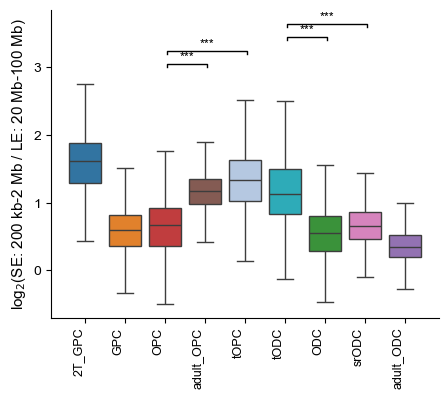

In [27]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


order = [
    "2T_GPC",
    "GPC",
    "OPC",
    "adult_OPC",
    "tOPC",
    "tODC",
    "ODC",
    "srODC",
    "adult_ODC",
]

focus_pairs = {
    ("OPC", "tOPC"),
    ("OPC", "adult_OPC"),
    # ("tOPC", "tODC"),
    ("tODC", "ODC"),
    ("tODC", "srODC"),
}

palette = {
    "2T_GPC": "#1f77b4",
    "GPC": "#ff7f0e",
    "OPC": "#d62728",
    "adult_OPC": "#8c564b",
    "tOPC": "#aec7e8",
    "tODC": "#17becf",
    "ODC": "#2ca02c",
    "srODC": "#e377c2",
    "adult_ODC": "#9467bd",
}

group_counts = plot_df["oL3"].value_counts().reindex(order)
xtick_labels = [f"{group}" for group in order]

axis_label = globals().get(
    "se_le_axis_label",
    "log$_2$(SE: 200 kb-2 Mb / LE: 20 Mb-100 Mb)"
)

def p_to_star(p):
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def rank_biserial_from_samples(x, y):
    test = mannwhitneyu(x, y, alternative="two-sided")
    n1, n2 = len(x), len(y)
    rbc = 1 - (2 * test.statistic) / (n1 * n2)
    return test.statistic, rbc, test.pvalue


pairs = [(order[i], order[j]) for i in range(len(order)) for j in range(i + 1, len(order))]
summary_rows = []
for left, right in pairs:
    left_vals = plot_df.loc[plot_df["oL3"] == left, "log2_SE_over_LE_ratio"].to_numpy()
    right_vals = plot_df.loc[plot_df["oL3"] == right, "log2_SE_over_LE_ratio"].to_numpy()

    if len(left_vals) == 0 or len(right_vals) == 0:
        print(f"Skipping {left} -> {right}: empty group")
        continue

    stat, rbc, pvalue = rank_biserial_from_samples(left_vals, right_vals)
    summary_rows.append(
        {
            "left": left,
            "right": right,
            "n_left": len(left_vals),
            "n_right": len(right_vals),
            "median_left": np.median(left_vals),
            "median_right": np.median(right_vals),
            "delta_median": np.median(right_vals) - np.median(left_vals),
            "mw_u": stat,
            "pvalue": pvalue,
            "rank_biserial": rbc,
            "focus_transition": (left, right) in focus_pairs,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df["p_adj_fdr"] = multipletests(summary_df["pvalue"], method="fdr_bh")[1]
summary_df["signif_fdr"] = summary_df["p_adj_fdr"].map(p_to_star)
summary_df["transition"] = summary_df["left"] + " -> " + summary_df["right"]

display_cols = [
    "transition",
    "n_left",
    "n_right",
    "median_left",
    "median_right",
    "delta_median",
    "rank_biserial",
    "pvalue",
    "p_adj_fdr",
]
print("Adjacent-pair statistics (cell-level):")
display(summary_df[display_cols].round(4))

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=plot_df,
    x="oL3",
    y="log2_SE_over_LE_ratio",
    order=order,
    hue="oL3",
    palette=palette,
    legend=False,
    showfliers=False,
    ax=ax,
)

# annotate only focus_pairs
annot_rows = summary_df[summary_df["focus_transition"]].reset_index(drop=True)
ymax = plot_df["log2_SE_over_LE_ratio"].max()
pair_order = list(order)
for i, row in annot_rows.iterrows():
    pair_idx = pair_order.index(row["left"])
    x1, x2 = pair_idx + 0.05, pair_order.index(row["right"]) + 0.05
    y = 3 + i * 0.2
    ax.plot([x1, x1, x2, x2], [y, y + 0.05, y + 0.05, y], lw=1, c="black")
    ax.text(
        (x1 + x2) / 2,
        y + 0.055,
        row["signif_fdr"],
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xlabel("")
ax.set_ylabel(axis_label, fontsize=11)
ax.set_xticklabels(xtick_labels ,rotation = 90,ha="right", fontsize=9)
sns.despine(ax=ax, top=True, right=True)

# plt.savefig('OPDC_SE_LE_boxplot.pdf', dpi=200)

## celltype difference

In [22]:
whole_ratio['L3'] = cellID_merged['L3']
whole_ratio['L2'] = cellID_merged['L2']

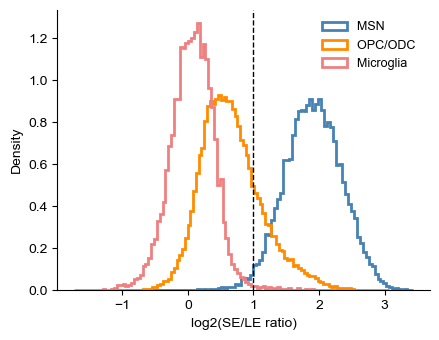

In [23]:
import matplotlib.pyplot as plt

celltypes = ["MSN", "OPC/ODC", "Microglia"]

colors = {
    "MSN": "steelblue",
    "OPC/ODC": "darkorange",
    "Microglia": "lightcoral",
}

fig, ax = plt.subplots(figsize=(4.5, 3.5))

for celltype in celltypes:
    if celltype == "MSN":
        subset_ratio = whole_ratio[whole_ratio["L2"] == "MSN"]
    elif celltype == "OPC/ODC":
        subset_ratio = whole_ratio[whole_ratio["L2"].isin(["OPC", "ODC","GPC"])]
    else:
        subset_ratio = whole_ratio[whole_ratio["L3"].isin(["MGC-1", "MGC-2"])]

    x = subset_ratio["log2_SE_over_LE_ratio"].dropna().to_numpy()

    ax.hist(
        x,
        bins=100,
        density=True,
        histtype="step",
        linewidth=2,
        color=colors[celltype],
        label=f"{celltype} ",
    )

ax.axvline(1, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("log2(SE/LE ratio)")
ax.set_ylabel("Density")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
# plt.savefig("SE_LE_density_by_celltype.pdf", bbox_inches="tight")
plt.show()

## Test a single file

In [24]:
hic_contact = pd.read_csv('/tuba/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_rmbkl/DLPFC_210111/20210111-1863-preAb-PFC-B12_A12.contact.rmbkl.tsv.gz',sep = '\t',header=None)
hic_contact.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,A00817:203:HV57GDSXY:1:1321:1615:23703,chr1,821715,chr1,822720,-,-,UU,gap,mask,R1-2,0,na
1,A00817:203:HV57GDSXY:2:1462:30400:29465,chr1,894068,chr1,902895,-,+,UU,gap,mask,R1-2,0,na
2,A00817:203:HV57GDSXY:1:1505:23800:17127,chr1,984535,chr1,986455,+,+,UU,NlaIII,mask,R2_rescue,5,"MboI_3,NlaIII_both"
3,A00817:203:HV57GDSXY:3:2157:8034:21762,chr1,1010671,chr1,32273486,-,-,UU,NlaIII,all,R2,5,NlaIII_both
4,A00817:203:HV57GDSXY:2:1368:20030:5963,chr1,1022867,chr1,1026718,-,+,UU,gap,mask,R1-2,0,na


In [25]:
hic_contact = hic_contact[hic_contact[1] == hic_contact[3]].copy()
hic_contact.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,A00817:203:HV57GDSXY:1:1321:1615:23703,chr1,821715,chr1,822720,-,-,UU,gap,mask,R1-2,0,na
1,A00817:203:HV57GDSXY:2:1462:30400:29465,chr1,894068,chr1,902895,-,+,UU,gap,mask,R1-2,0,na
2,A00817:203:HV57GDSXY:1:1505:23800:17127,chr1,984535,chr1,986455,+,+,UU,NlaIII,mask,R2_rescue,5,"MboI_3,NlaIII_both"
3,A00817:203:HV57GDSXY:3:2157:8034:21762,chr1,1010671,chr1,32273486,-,-,UU,NlaIII,all,R2,5,NlaIII_both
4,A00817:203:HV57GDSXY:2:1368:20030:5963,chr1,1022867,chr1,1026718,-,+,UU,gap,mask,R1-2,0,na


In [26]:
SE_lo, SE_hi = 200_000, 2_000_000
LE_lo, LE_hi = 20_000_000, 100_000_000

dist = (hic_contact[4] - hic_contact[2]).abs().to_numpy()
dist = dist[dist > 0]

rng = np.random.default_rng(0)
results = []

for n in [10_000, 8_000, 6_000]:
    for i in range(10000):
        x = rng.choice(dist, size=n, replace=False)
        se = ((x >= SE_lo) & (x < SE_hi)).sum()
        le = ((x >= LE_lo) & (x < LE_hi)).sum()
        results.append([n, i, se, le, np.log2(se / le) if se > 0 and le > 0 else np.nan])

random_subset_log2_se_le = pd.DataFrame(
    results,
    columns=['n_contacts', 'repeat', 'SE_count', 'LE_count', 'log2_SE_LE']
)

random_subset_log2_se_le.groupby('n_contacts')['log2_SE_LE'].describe()

,count,mean,std,min,25%,50%,75%,max
n_contacts,,,,,,,,
6000,10000.0,2.944302,0.085299,2.640799,2.885993,2.942768,3.001822,3.292782
8000,10000.0,2.945119,0.074716,2.689509,2.894466,2.943720,2.993594,3.224044
10000,10000.0,2.945315,0.065225,2.715614,2.901156,2.944561,2.988229,3.204294
